In [73]:
import numpy as np
import pandas as pd
from cyvcf2 import VCF
import os
from scipy import stats
from qqman import qqman

phenotype_file = "~/public/ps3/ps3_gwas.phen"
vcf_file = os.path.expanduser("~/public/ps3/ps3_gwas.vcf.gz")
vcf = VCF(vcf_file)

In [51]:
# read phenotypes
phen_df = pd.read_csv(phenotype_file, delim_whitespace=True, header=None)
phen_df.columns = ["FID", "IID", "PHENO"]
phen_df

,FID,IID,PHENO
0,NA06984,NA06984,-1.893857
1,NA06985,NA06985,1.888449
2,NA06986,NA06986,-0.144653
3,NA06989,NA06989,2.467882
4,NA06994,NA06994,-1.416886
...,...,...,...
202,NA19239,NA19239,0.566362
203,NA19247,NA19247,-0.152724
204,NA19248,NA19248,0.896982
205,NA19256,NA19256,-1.016228


In [52]:
# read vcf file
vcf = VCF(vcf_file)

sample_ids = np.array(vcf.samples)
n_samples = len(sample_ids)

print("Number of individuals in VCF:", n_samples)

Number of individuals in VCF: 207


In [53]:
# ----------------------------
genotypes = []
chroms = []
positions = []

for variant in vcf:
    # variant.genotypes gives [ [0,1,True], ... ]
    # first two entries are alleles
    gt = np.array([g[0] + g[1] if g[0] != -1 else np.nan 
                   for g in variant.genotypes])
    genotypes.append(gt)
    chroms.append(variant.CHROM)
    positions.append(variant.POS)

G = np.array(genotypes).T  # transpose to get individuals x SNPs

In [54]:
print(G.shape) # individuals x SNPs
G

(207, 917845)


array([[0, 0, 0, ..., 0, 0, 0],
       [1, 1, 0, ..., 1, 1, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 2],
       [0, 0, 0, ..., 0, 0, 1],
       [0, 0, 0, ..., 0, 0, 2]])

In [56]:
print(chroms[:10])
print(positions[:10])

['10', '10', '10', '10', '10', '10', '10', '10', '10', '10']
[98087, 111955, 126070, 134767, 135656, 135708, 135853, 148325, 151997, 158946]


In [31]:
phenotypes = phen_df["PHENO"].values
phenotype_ids = phen_df["IID"].values
id_to_pheno = dict(zip(phenotype_ids, phenotypes))

aligned_phenotypes = np.array([id_to_pheno[s] for s in sample_ids])


In [69]:
# do linear regression on each SNP
def gwas_linear(G, y):
    """
    G: (n_samples, n_snps)
    y: (n_samples,)
    Returns: beta, pvals
    """
    n = G.shape[0]

    # Center variables (important!)
    G_centered = G - G.mean(axis=0)
    y_centered = y - y.mean()

    # Compute beta for each SNP
    numerator = np.sum(G_centered * y_centered[:, None], axis=0)
    denominator = np.sum(G_centered**2, axis=0)
    beta = numerator / denominator

    # Predicted values
    y_hat = G_centered * beta

    # Residual variance
    rss = np.sum((y_centered[:, None] - y_hat)**2, axis=0)
    sigma2 = rss / (n - 2)

    # Standard error
    se = np.sqrt(sigma2 / denominator)

    # t-statistic
    t_stat = beta / se

    # Two-sided p-value
    pvals = 2 * stats.t.sf(np.abs(t_stat), df=n-2)

    return beta, pvals

beta, pvals = gwas_linear(G, aligned_phenotypes) # subset for now
pvals

array([1.09734452e-01, 3.63471251e-01, 5.04263951e-01, ...,
       1.05171331e-03, 3.19168211e-01, 4.36267875e-05])

In [ ]:
unique_chroms = np.unique(chroms)
    
# Sort chromosomes naturally
try:
    unique_chroms = sorted(unique_chroms, key=lambda x: int(x))
except:
    unique_chroms = sorted(unique_chroms)

cumulative_pos = 0
x_vals = []
xticks = []
xtick_labels = []

plt.figure(figsize=(12,6))

for i, chrom in enumerate(unique_chroms):
    mask = chroms == chrom
    pos = positions[mask]
    p = pvals[mask]

    # Sort by position within chromosome
    order = np.argsort(pos)
    pos = pos[order]
    p = p[order]

    # Create cumulative genomic coordinate
    pos_shifted = pos + cumulative_pos

    plt.scatter(pos_shifted, -np.log10(p), s=6)

    xticks.append(pos_shifted.mean())
    xtick_labels.append(str(chrom))

    cumulative_pos = pos_shifted.max()

plt.xticks(xticks, xtick_labels)
plt.xlabel("Chromosome")
plt.ylabel("-log10(p)")

# Genome-wide significance line
plt.axhline(-np.log10(5e-8), linestyle='--')

plt.tight_layout()
plt.show()

In [75]:
assoc_df = pd.DataFrame({
    "CHR": chroms,
    "BP": positions,
    "BETA": beta,
    "P": pvals
})
assoc_df["CHR"] = pd.to_numeric(assoc_df["CHR"], errors="coerce")
assoc_df = assoc_df.sort_values(["CHR", "BP"]).reset_index(drop=True)

print(assoc_df.head())



   CHR      BP      BETA             P
0    1  752566 -0.302728  5.049645e-04
1    1  752721 -0.407888  9.056280e-07
2    1  776546 -0.462037  4.919576e-04
3    1  798959  0.296714  4.859662e-04
4    1  800007 -0.570414  9.751824e-03


[WARNING]: Column 'SNP' not found!


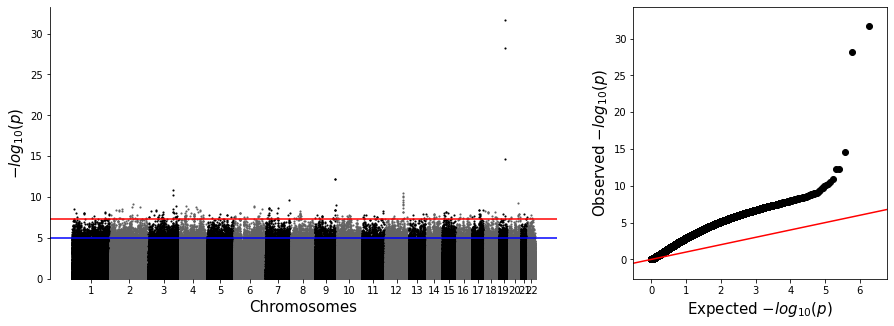

In [76]:
# data = pd.read_csv("ps3_gwas.assoc.linear", delim_whitespace=True)
fig, (ax0, ax1) = plt.subplots(1, 2, gridspec_kw={'width_ratios': [2, 1]})
fig.set_size_inches((15, 5))
qqman.manhattan(assoc_df, ax=ax0)
qqman.qqplot(assoc_df, ax=ax1)

In [66]:
data = pd.read_csv("~/public/ps3/ps3_gwas.assoc.linear", delim_whitespace=True)

In [67]:
data

,CHR,SNP,BP,A1,TEST,NMISS,BETA,STAT,P
0,10,rs11252127,98087,T,ADD,207,-0.20430,-1.6060,0.109700
1,10,rs7909677,111955,G,ADD,207,0.19160,0.9108,0.363500
2,10,rs11591988,126070,T,ADD,207,-0.14700,-0.6690,0.504300
3,10,rs12768206,134767,A,ADD,207,-0.05717,-0.6032,0.547100
4,10,rs10904561,135656,G,ADD,207,-0.17850,-1.4710,0.142900
...,...,...,...,...,...,...,...,...,...
835556,9,rs9777369,141018423,T,ADD,207,0.50510,3.3960,0.000822
835557,9,rs11137376,141025328,A,ADD,207,0.36110,2.1310,0.034320
835558,9,rs17583562,141026318,A,ADD,207,-0.71220,-3.3240,0.001052
835559,9,rs11137379,141027939,A,ADD,207,-0.13960,-0.9986,0.319200


In [ ]:
# try adding covariates:
